In [4]:
!pip install "numpy<2.0.0"
# Then restart terminal

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 126.4 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.0
    Uninstalling numpy-2.2.0:
      Successfully uninstalled numpy-2.2.0


In [1]:
!pip install -qq medmnist
!pip install -qq av
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import sys
sys.path.append('/home/ubuntu/.lambda/lib/python3.10/site-packages')

In [3]:
import os
import cv2
import numpy as np
import tensorflow as tf  # for data preprocessing only
import keras
import av
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

2024-12-16 20:03:20.350240: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-16 20:03:20.362283: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-16 20:03:20.376835: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-16 20:03:20.381148: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-16 20:03:20.391936: I tensorflow/core/platform/cpu_feature_guar

In [4]:
DATA_DIR = 'HandWashDataset'

CLASSES = ['Step_1', 'Step_2_Left', 'Step_2_Right', 'Step_3', 
           'Step_4_Left', 'Step_4_Right', 'Step_5_Left', 'Step_5_Right', 
           'Step_6_Left', 'Step_6_Right', 'Step_7_Left', 'Step_7_Right']

LABELS_TO_ID = { 'Step_1' : 0, 'Step_2_Left' : 1, 'Step_2_Right' : 1, 
                'Step_3' : 2, 'Step_4_Left' : 3, 'Step_4_Right' : 3, 
                'Step_5_Left' : 4, 'Step_5_Right' : 4, 'Step_6_Left' : 5,
                'Step_6_Right' : 5, 'Step_7_Left' : 6, 'Step_7_Right' : 6}

ACTUAL_CLASSES = [1, 2, 3, 4, 5, 6, 7]

# LABELS_TO_ID = { label : i for i, label in enumerate(CLASSES) }

TEST_SIZE = 0.2
VAL_SIZE = 0.2
DATASET_SEED = 81

FRAME_SIZE = (360, 240)
SCALE = 255.0
CLIP_LENGTH = 60 # 120 runs into errors

INPUT_SHAPE = (210, 270, 1) # coordinates are inverted for some reason
NUM_FRAMES = 3

# TRAINING
BATCH_SIZE = 32 # down from 64 because of frame size
NUM_CLASSES = len(ACTUAL_CLASSES)
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 100

In [5]:
def prepare_dataset(data_dir, classes, test_size=TEST_SIZE, val_size=VAL_SIZE, random_state=DATASET_SEED):
    video_lengths = []
    for class_name in classes:
        class_dir = os.path.join(data_dir, class_name)
        videos = os.listdir(class_dir)
        for video_file in videos:
            if os.path.isdir(video_file):
                continue
            video_path = os.path.join(class_dir, video_file)
            video_reader = cv2.VideoCapture(video_path)
            frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
            video_lengths.append((class_name, video_path, frames_count))
            video_reader.release()

    train_videos, test_val_videos = train_test_split(video_lengths, test_size=test_size+val_size, random_state=random_state)
    val_videos, test_videos = train_test_split(test_val_videos, test_size=test_size/(test_size+val_size), random_state=random_state)

    return train_videos, val_videos, test_videos

In [6]:
def read_video_pyav(container, indices, new_size = FRAME_SIZE, scale=SCALE):
    '''Decode the video with PyAV decoder.
    Args:
        container (`av.container.input.InputContainer`): PyAV container.
        indices (`List[int]`): List of frame indices to decode.
    Returns:
        result (np.ndarray): np array of decoded frames of shape (num_frames, height, width, 3).'''
    frames = []
    container.seek(0)
    start_index = indices[0]
    end_index = indices[-1]
    for i, frame in enumerate(container.decode(video=0)):
        if i > end_index:
            break
        if i >= start_index and i in indices:
            new_frame = frame.to_ndarray(format="rgb24")
            new_frame = cv2.cvtColor(new_frame, cv2.COLOR_RGB2GRAY)
            new_frame = new_frame / scale
            new_frame = cv2.resize(new_frame, new_size)
            frames.append(new_frame)
    return np.stack(frames)

def sample_frame_indices(frame_sample_rate, seg_len, clip_len=CLIP_LENGTH):
    '''Sample a given number of frame indices from the video.
    Args:
        clip_len (`int`): Total number of frames to sample.
        frame_sample_rate (`int`): Sample every n-th frame.
        seg_len (`int`): Maximum allowed index of sample's last frame.
    Returns:
        indices (`List[int]`): List of sampled frame indices'''
    converted_len = int(clip_len * frame_sample_rate)
    # end_idx = np.random.randint(converted_len, seg_len)
    end_idx = seg_len # Always picking the last CLIP_LENGTH many frames
    start_idx = end_idx - converted_len
    indices = np.linspace(start_idx, end_idx, num=clip_len)
    indices = np.clip(indices, start_idx, end_idx - 1).astype(np.int64)
    return indices

def download_and_prepare_dataset(video_directories: list):
    """Utility function to download dataset
    Arguments:
        list of addresses of videos
    Returns:
        list of videos, each of different dimension"""
    np_videos = []
    for address in video_directories:
        vid_container = av.open(address)
        vid_indices = sample_frame_indices(frame_sample_rate=1, seg_len=vid_container.streams.video[0].frames)
        np_videos.append(read_video_pyav(container=vid_container, indices=vid_indices))
    return np_videos

def preprocess_dataset(list_of_videos, list_of_labels, new_size=FRAME_SIZE, clip_len=CLIP_LENGTH):
    """Normalize and resize the dataset"""
    clips = clip_len // NUM_FRAMES
    resized_list = np.zeros((len(list_of_videos) * clips, NUM_FRAMES, FRAME_SIZE[1], FRAME_SIZE[0]), dtype=np.float32)
    resized_labels = np.zeros((len(list_of_videos) * clips), dtype = np.float32)
    for i, video in enumerate(list_of_videos):
        for j, frame in enumerate(video):
            clip_num = ((i * CLIP_LENGTH) + j) // 3
            if j % 3 == 0:
                resized_labels[clip_num] = list_of_labels[i]
            resized_list[clip_num][j % 3] = frame
            
    return (resized_list, resized_labels)

In [7]:
train_info, val_info, test_info = prepare_dataset(DATA_DIR, CLASSES)

train_addr = [info[1] for info in train_info]
train_names = [LABELS_TO_ID[info[0]] for info in train_info]

val_addr = [info[1] for info in val_info]
val_names = [LABELS_TO_ID[info[0]] for info in val_info]

test_addr = [info[1] for info in test_info]
test_names = [LABELS_TO_ID[info[0]] for info in test_info]

In [8]:
train_videos, train_labels = preprocess_dataset(download_and_prepare_dataset(train_addr), train_names)
print("done with train")
val_videos, val_labels = preprocess_dataset(download_and_prepare_dataset(val_addr), val_names)
print("done with val")
test_videos, test_labels = preprocess_dataset(download_and_prepare_dataset(test_addr), test_names)

done with train
done with val


In [9]:
def preprocess(frame: tf.Tensor, label: tf.Tensor):
    """Preprocess the frames tensors and parse the labels."""
    frame = frame[..., tf.newaxis]
    frame = tf.image.random_crop(frame, size=(NUM_FRAMES, INPUT_SHAPE[0], INPUT_SHAPE[1], INPUT_SHAPE[2]))
    frame = tf.image.random_flip_up_down(frame)
    frame = tf.image.random_brightness(frame, 0.2)
    return frame, label

def prepare_dataloader(
    videos: np.ndarray,
    labels: np.ndarray,
    loader_type: str = "train",
    batch_size: int = BATCH_SIZE,
):
    """Utility function to prepare the dataloader."""
    dataset = tf.data.Dataset.from_tensor_slices((videos, labels))

    if loader_type == "train":
        dataset = dataset.shuffle(BATCH_SIZE * 2)

    dataloader = (
        dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )
    return dataloader

In [10]:
trainloader = prepare_dataloader(train_videos, train_labels, "train")
validloader = prepare_dataloader(val_videos, val_labels, "valid")
testloader = prepare_dataloader(test_videos, test_labels, "test")

I0000 00:00:1734379926.313637    4071 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1734379926.357869    4071 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1734379926.361574    4071 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1734379926.367235    4071 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, TimeDistributed, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical

In [12]:
print(NUM_CLASSES)

7


In [13]:
new_input = (NUM_FRAMES, INPUT_SHAPE[0], INPUT_SHAPE[1], INPUT_SHAPE[2])

model = Sequential([
    TimeDistributed(Conv2D(48, (7, 7), activation='relu', input_shape=new_input)),
    TimeDistributed(BatchNormalization()),
    TimeDistributed(MaxPooling2D((2, 2))),
    TimeDistributed(Dropout(0.25)),
    
    TimeDistributed(Conv2D(128, (5, 5), activation='relu')),
    TimeDistributed(BatchNormalization()),
    TimeDistributed(MaxPooling2D((2, 2))),
    
    TimeDistributed(Conv2D(196, (3, 3), activation='relu')),
    TimeDistributed(BatchNormalization()),
    TimeDistributed(MaxPooling2D((2, 2))),
    
    TimeDistributed(Conv2D(256, (3, 3), activation='relu')),
    TimeDistributed(BatchNormalization()),
    TimeDistributed(MaxPooling2D((2, 2))),
    
    TimeDistributed(Conv2D(384, (3, 3), activation='relu')),
    TimeDistributed(BatchNormalization()),
    TimeDistributed(MaxPooling2D((2, 2))),
    
    TimeDistributed(Conv2D(896, (3, 3), activation='relu')),
    TimeDistributed(BatchNormalization()),
    TimeDistributed(MaxPooling2D((2, 2))),
    
    TimeDistributed(Flatten()),
    LSTM(256, activation='tanh'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
    ],
)

history = model.fit(trainloader, epochs=EPOCHS, validation_data=validloader)

_, accuracy, top_5_accuracy = model.evaluate(testloader)
print(f"Test accuracy: {round(accuracy * 100, 2)}%")
print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

Epoch 1/100


/usr/lib/python3/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2024-12-16 20:12:20.002050: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90400
W0000 00:00:1734379940.148600   14051 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379940.178957   14051 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379940.182594   14051 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379940.209094   14051 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379940.219030   14051 gpu_timer.cc:114] Skipping t

112/113 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.2082 - loss: 2.9704 - top-5-accuracy: 0.7991

W0000 00:00:1734379990.481643   14045 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379990.483301   14045 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379990.484878   14045 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379990.485906   14045 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379990.487110   14045 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379990.488333   14045 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379990.489972   14045 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379990.490930   14045 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379990.492057   14045 gp

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.2081 - loss: 2.9708 - top-5-accuracy: 0.7989

W0000 00:00:1734379991.527818   14047 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379991.529090   14047 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379991.530544   14047 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379991.532970   14047 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379991.540198   14047 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379991.542760   14047 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379991.545077   14047 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379991.548638   14047 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379991.550631   14047 gp

113/113 ━━━━━━━━━━━━━━━━━━━━ 65s 469ms/step - accuracy: 0.2081 - loss: 2.9712 - top-5-accuracy: 0.7987 - val_accuracy: 0.1008 - val_loss: 2.0320 - val_top-5-accuracy: 0.8392
Epoch 2/100


W0000 00:00:1734379996.440737   14045 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379996.442020   14045 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379996.443383   14045 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379996.444930   14045 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379996.446352   14045 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379996.447964   14045 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379996.449547   14045 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379996.451277   14045 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1734379996.452871   14045 gp

113/113 ━━━━━━━━━━━━━━━━━━━━ 50s 445ms/step - accuracy: 0.2171 - loss: 2.6909 - top-5-accuracy: 0.7981 - val_accuracy: 0.1292 - val_loss: 2.3992 - val_top-5-accuracy: 0.7975
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 51s 449ms/step - accuracy: 0.2494 - loss: 2.4856 - top-5-accuracy: 0.8166 - val_accuracy: 0.1533 - val_loss: 2.3263 - val_top-5-accuracy: 0.8108
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 82s 448ms/step - accuracy: 0.3047 - loss: 2.2298 - top-5-accuracy: 0.8463 - val_accuracy: 0.2200 - val_loss: 2.1861 - val_top-5-accuracy: 0.8367
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 51s 450ms/step - accuracy: 0.3435 - loss: 2.0292 - top-5-accuracy: 0.8837 - val_accuracy: 0.1517 - val_loss: 3.5718 - val_top-5-accuracy: 0.8542
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 51s 451ms/step - accuracy: 0.3957 - loss: 1.9021 - top-5-accuracy: 0.8992 - val_accuracy: 0.3200 - val_loss: 2.0415 - val_top-5-accuracy: 0.8625
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 51s 452ms/step - accuracy: 0.4492 - loss:

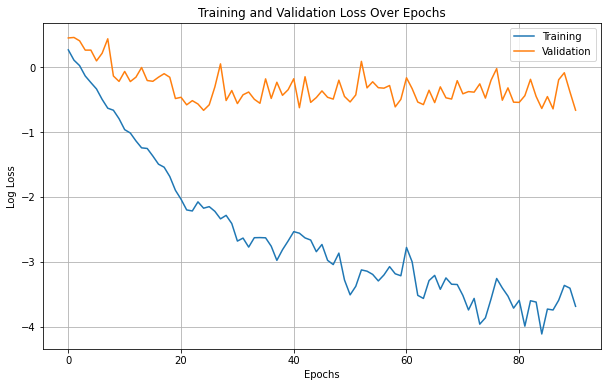

In [14]:
# Plotting both
plt.figure(figsize=(10, 6))
plt.plot(np.log(history.history['loss'][9:]), label='Training')
plt.plot(np.log(history.history['val_loss'][9:]), label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step


2024-12-16 21:55:35.257495: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


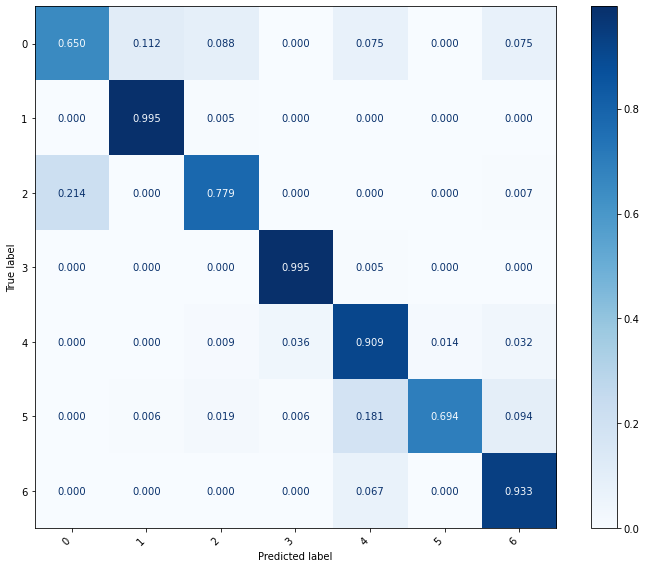

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Step 1: Get predictions from the trained model
y_pred_probs = model.predict(testloader)  # Predict probabilities for each class

# Step 2: Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 3: Get true labels
y_true = np.concatenate([y for x, y in testloader], axis=0)

# Step 4: Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Making each entry a percentage of the row sum
cm_percentage = np.round(cm.astype('float') / cm.sum(axis=1)[:, np.newaxis], 3)

# Step 5: Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=range(7))
fig, ax = plt.subplots(figsize=(10, 8)) 
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.3f')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()  

plt.show()

In [16]:
model.save_weights('LSTM_alt.weights.h5')